# Stuttering Detection: Probabilistic Analysis (Final Verified Version)
---

In [ ]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score
from src.data import DataManager
from src.models import NaiveBayesModel, LDAModel
import pandas as pd
from sklearn.naive_bayes import GaussianNB


# Constants
RANDOM_SEED = 42
SAMPLE_LIMIT = None
STRICT_LABELS = True
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
FEATURE_DIR = "data/features"
fluent_dir = os.path.join(FEATURE_DIR, "fluent")
disfluent_dir = os.path.join(FEATURE_DIR, "disfluent")

## Step 1: Loading
Calling `generate_label_dict` with all required parameters.

In [2]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

# Passing the correct keyword arguments to avoid default path fallback
X, y = manager.load_from_folders(
    fluent_dir=fluent_dir, 
    disfluent_dir=disfluent_dir, 
    limit=SAMPLE_LIMIT, 
    label_dict=label_dict
)

print(f"Data Loaded: {len(X)} samples.")
manager.analyze_distribution()

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).
Data Loaded: 14452 samples.
--- Data Distribution ---
Fluent (0): 7784 (53.9%)
Disfluent (1): 6668 (46.1%)
Total: 14452


## Step 2: Splitting & Balancing

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# PREPROCESS (Explicit fit=False to prevent leakage)
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_val_final = manager.preprocess(X_val, method="standard", fit=False)
X_test_final = manager.preprocess(X_test, method="standard", fit=False)

## Step 3: Probabilistic Baselines (Team Models)

In [4]:
nb_baseline = NaiveBayesModel(model_name="NB_Baseline")
nb_baseline.train(X_train_final, y_train_bal)
print("Naive Bayes (Gaussian) Baseline:")
nb_baseline.evaluate(X_val_final, y_val)

lda_baseline = LDAModel(model_name="LDA_Baseline", solver='svd')
lda_baseline.train(X_train_final, y_train_bal)
print("\nNormal Bayes (LDA) Baseline:")
lda_baseline.evaluate(X_val_final, y_val)

[Model: NB_Baseline] Initialized.
[NB_Baseline] Training on 10896 samples...
Naive Bayes (Gaussian) Baseline:

--- Evaluation: NB_Baseline ---
Accuracy: 0.6827
Precision: 0.6950
Recall: 0.5560
F1: 0.6178

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      924             244            
True: Stutter(1)     444             556            
[Model: LDA_Baseline] Initialized.
[LDA_Baseline] Training Bayesian Probability Map...

Normal Bayes (LDA) Baseline:

--- Evaluation: LDA_Baseline ---
Accuracy: 0.8132
Precision: 0.8122
Recall: 0.7740
F1: 0.7926

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      989             179            
True: Stutter(1)     226             774            


{'accuracy': 0.8131918819188192,
 'precision': 0.8121720881427072,
 'recall': 0.774,
 'f1': 0.7926267281105991,
 'confusion_matrix': array([[989, 179],
        [226, 774]])}

## Step 4: Hypertuning optimized LDA

In [ ]:
print("--- [STARTING PROBABILISTIC HYPERTUNING] ---")
X_combined = np.vstack((X_train_final, X_val_final))
y_combined = np.hstack((y_train_bal, y_val))

split_indices = np.hstack((
    -1 * np.ones(len(X_train_final)),
    np.zeros(len(X_val_final))
))
pds = PredefinedSplit(test_fold=split_indices)

# 1. Tuning LDA
lda_grid = [
    {'solver': ['svd']}, 
    {'solver': ['lsqr', 'eigen'], 'shrinkage': ['auto', 0.1, 0.5, 0.9]}
]
gs_lda = GridSearchCV(LinearDiscriminantAnalysis(), lda_grid, cv=pds, scoring="accuracy", n_jobs=-1)
gs_lda.fit(X_combined, y_combined)
pd.DataFrame(gs_lda.cv_results_).to_csv("reports/lda_hypertuning_benchmarks.csv", index=False)

# 2. Tuning Naive Bayes
nb_params = {'var_smoothing': np.logspace(0, -9, num=100)}
gs_nb = GridSearchCV(GaussianNB(), nb_params, cv=pds, scoring='accuracy', n_jobs=-1)
gs_nb.fit(X_combined, y_combined)
pd.DataFrame(gs_nb.cv_results_).to_csv("reports/naive_bayes_hypertuning_benchmarks.csv", index=False)

print(f"Benchmarking data saved to reports/ folders.")
print(f"Best LDA Params: {gs_lda.best_params_}")
print(f"Best NB Params: {gs_nb.best_params_}")


--- [STARTING LDA HYPERTUNING] ---
Fitting 1 folds for each of 9 candidates, totalling 9 fits

Best Params: {'shrinkage': 0.1, 'solver': 'lsqr'}


## Step 5: Wrap Hypertuned Model into Team Class
We re-wrap the result into `LDAModel` for project consistency.

[Model: Optimized_LDA] Initialized.
[Optimized_LDA] Training Bayesian Probability Map...
--- Final Performance (Test Set) ---

--- Evaluation: Optimized_LDA ---
Accuracy: 0.8160
Precision: 0.8249
Recall: 0.7630
F1: 0.7927

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      1006            162            
True: Stutter(1)     237             763            


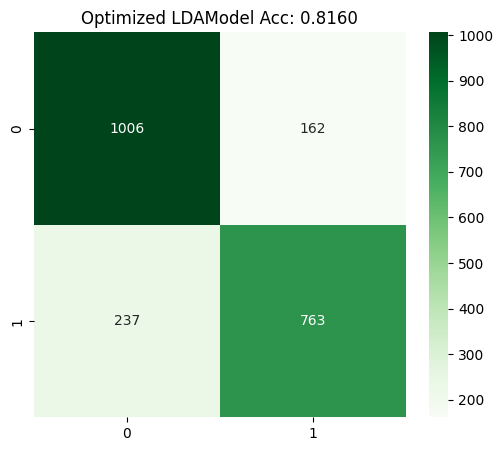

In [ ]:
# Train Final Optimized Models
final_lda = LDAModel(model_name="Optimized_LDA", **gs_lda.best_params_)
final_lda.train(X_train_final, y_train_bal)

# Note: We pass var_smoothing to the Team Wrapper
final_nb = NaiveBayesModel(model_name="Optimized_NB")
final_nb.model = gs_nb.best_estimator_ # Directly inject optimized sklearn model

print("--- Final Performance (Test Set) ---")
res_lda = final_lda.evaluate(X_test_final, y_test)
res_nb = final_nb.evaluate(X_test_final, y_test)

# HARVEST FOR LEADERBOARD
lda_final_accuracy, lda_final_f1 = res_lda['accuracy'], res_lda['f1']
nb_final_accuracy, nb_final_f1 = res_nb['accuracy'], res_nb['f1']

print(f"\n[HARVEST] LDA Final F1: {lda_final_f1:.4f}")
print(f"[HARVEST] NB Final F1: {nb_final_f1:.4f}")

# Plot Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, final_lda.predict(X_test_final)), annot=True, fmt='d', cmap='Greens', ax=ax1)
ax1.set_title(f"Optimized LDA (Acc: {lda_final_accuracy*100:.1f}%)")
sns.heatmap(confusion_matrix(y_test, final_nb.model.predict(X_test_final)), annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title(f"Optimized Naive Bayes (Acc: {nb_final_accuracy*100:.1f}%)")
plt.show()


## Step 6: Persistence

In [7]:
os.makedirs("models", exist_ok=True)
final_lda.save("models/probabilistic_lda_best.pkl")

[Optimized_LDA] Model saved to models/probabilistic_lda_best.pkl


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Xt_pca = pca.fit_transform(X_train_final)
Xtest_pca = pca.transform(X_test_final)

# Fit 2D proxies
lda_2d = LinearDiscriminantAnalysis(**gs_lda.best_params_).fit(Xt_pca, y_train_bal)
nb_2d = GaussianNB(**gs_nb.best_params_).fit(Xt_pca, y_train_bal)

h = .05
x_min, x_max = Xt_pca[:, 0].min() - 1, Xt_pca[:, 0].max() + 1
y_min, y_max = Xt_pca[:, 1].min() - 1, Xt_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for ax, model, title, cmap in zip([ax1, ax2], [lda_2d, nb_2d], ["LDA Boundary", "NB Boundary"], ["Greens", "Blues"]):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    ax.scatter(Xtest_pca[:, 0], Xtest_pca[:, 1], c=y_test, edgecolor='k', s=20, cmap=cmap)
    ax.set_title(title)

plt.suptitle("Probabilistic Decision Surfaces (PCA Space)")
plt.show()

# Final Persistence
os.makedirs("models", exist_ok=True)
joblib.dump(final_lda, "models/probabilistic_lda_best.joblib")
joblib.dump(final_nb.model, "models/probabilistic_nb_best.joblib")
print("[System] Both probabilistic models exported to models/ folder.")


In [ ]:

print("--- [AUTOMATED NAIVE BAYES STANDARDIZATION] ---")

# 1. Tuning
nb_params = {'var_smoothing': np.logspace(0, -9, num=100)}
gs_nb = GridSearchCV(GaussianNB(), nb_params, cv=pds, scoring='accuracy', n_jobs=-1)
gs_nb.fit(X_combined, y_combined)

# 2. Log Data
os.makedirs("reports", exist_ok=True)
pd.DataFrame(gs_nb.cv_results_).to_csv("reports/naive_bayes_hypertuning_benchmarks.csv", index=False)

# 3. Decision Boundary Plot
Xt_pca = PCA(n_components=2).fit_transform(X_train_final)
best_nb_2d = GaussianNB(**gs_nb.best_params_).fit(Xt_pca, y_train_bal)
h = .05
x_min, x_max = Xt_pca[:, 0].min() - 1, Xt_pca[:, 0].max() + 1
y_min, y_max = Xt_pca[:, 1].min() - 1, Xt_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = best_nb_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Blues')
plt.scatter(Xt_pca[:, 0], Xt_pca[:, 1], c=y_train_bal, edgecolor='k', alpha=0.6, cmap='Blues')
plt.title("Naive Bayes Decision Boundary (PCA Space)")
plt.show()

# 4. Save Best Model
os.makedirs("models", exist_ok=True)
joblib.dump(gs_nb.best_estimator_, "models/naive_bayes_best.joblib")

print(f"Done! Best Accuracy: {gs_nb.best_score_:.4f}")
print("Config saved to reports/ and Model saved to models/")
